## Current Model Formulation

In [2]:
# importing modules
using JuMP, MosekTools, Random, Plots, LinearAlgebra, DataFrames, HiGHS
plotlyjs()

WebIO._IJuliaInit()

Plots.PlotlyJSBackend()

### Model 1

In [3]:
model = Model(Mosek.Optimizer)

@variable(model, x[1:7]>=0)
for i in 1:6
    set_integer(x[i]) # imports can be in decimal, while the rest are integers
end

sizes = [114156, 366758, 130400, 3.5, 0.25, 61000, 0]

energy_prod_MWh = [470.5, 1942.5, 134, 0.00048, 0.000057, 69.5, 20000]
energy_prod_Wh = energy_prod_MWh * 10^6
yearly_Wh_prod_per_tech = energy_prod_Wh * (365*8)

running_costs_perMWh = [241, 241, 150, 110, 150, 102, 180]

running_costs_perWh = running_costs_perMWh/10^6

emissions_gperKWh = [670, 670, 1220, 40, 60, 1167, 110]
emissions_gperWh = emissions_gperKWh / 10^3
carbon_tax = 80/1000000 # conversion of $/ton to $/gram
emissions_costs_perWh = emissions_gperWh.*carbon_tax
total_running_costs_perWh = emissions_costs_perWh + running_costs_perWh
total_running_costs_perKWh = total_running_costs_perWh * 1000

@constraint(model, c1, sum(sizes.*x) <= 2.1*10^7)

## Running Cost Constraint
current_energycost_perKWh = 0.281 # costs of electricity $0.281 / kWH
@constraint(model, c2, sum((current_energycost_perKWh .- total_running_costs_perKWh).*x) >= 0)

## Building Cost Constraint
yearly_depreciation_cost = [89.4, 96, 67, 0.1, 0.1, 104, 200] # made up import number
sg_annual_energy_budget = 10 * 10^9
# fixed depreciation costs in millions
@constraint(model, c3, sum(yearly_depreciation_cost.*x) <= sg_annual_energy_budget)

## Diversity Constraints
total_energy_prod_year = sum(yearly_Wh_prod_per_tech.*x)
@constraint(model, c4, yearly_Wh_prod_per_tech[7] * x[7] <= 0.3*total_energy_prod_year)

## Emissions Constraints
# ~471g of carbon dioxide per kWH of electricity generated
SG_yearly_Wh = 57*10^12 # total energy generation in a year

reduction_factor = 0.7
max_emissions_kg_per_yr = 27*10^6*10^4 * reduction_factor
emissionlimit_g_peryr = 471 / 10^3 * SG_yearly_Wh * reduction_factor
emissions_produced_g = emissions_gperWh .* yearly_Wh_prod_per_tech .* x
@constraint(model, c5, sum(emissions_produced_g) <= emissionlimit_g_peryr)


@objective(model, Max, total_energy_prod_year)

print(model)
set_silent(model)


In [4]:
total_running_costs_perKWh_plus_storage = copy(total_running_costs_perKWh)
total_running_costs_perKWh_plus_storage[5:6] .+= 0.15
# total_running_costs_perKWh_plus_storage[6] += 0.15
total_running_costs_perKWh_plus_storage

7-element Vector{Float64}:
 0.29460000000000003
 0.29460000000000003
 0.24760000000000001
 0.1132
 0.30479999999999996
 0.34536
 0.1888

### Optimize and Solve the Model!

In [6]:
optimize!(model)

println("objective value $(objective_value(model)). Hence in gigawatt hours that would be about $(round(objective_value(model)/10^9, digits=2)) GWh. SG produced about 57,389 GWh in 2023.")

for (i, variable) in enumerate(all_variables(model))
    production = yearly_Wh_prod_per_tech[i]*value(variable)
    percentage_of_total = round(production / objective_value(model)*100, digits=2)
    println("$(name(variable)) = $(value(variable)). This is $(percentage_of_total)% of the total. Raw value is $(round(production/10^9, digits=2)) GWh")
end

objective value 5.284361182445714e13. Hence in gigawatt hours that would be about 52843.61 GWh. SG produced about 57,389 GWh in 2023.
x[1] = 1.0. This is 2.6% of the total. Raw value is 1373.86 GWh
x[2] = 4.0. This is 42.93% of the total. Raw value is 22688.4 GWh
x[3] = 0.0. This is 0.0% of the total. Raw value is 0.0 GWh
x[4] = 0.0. This is 0.0% of the total. Raw value is 0.0 GWh
x[5] = 7.7675248e7. This is 24.47% of the total. Raw value is 12928.27 GWh
x[6] = 0.0. This is 0.0% of the total. Raw value is 0.0 GWh
x[7] = 0.27145691005714284. This is 30.0% of the total. Raw value is 15853.08 GWh


### Constraint Report and Slackness in Constraints at optimal

In [8]:
function constraint_report(c::ConstraintRef)

    current_value = round(value(c), digits=3)
    rhs = round(normalized_rhs(c), digits=3)
    slack = rhs - current_value
    
    return (
        c_name = name(c),
        current_value,
        rhs,
        slack = round(slack, digits=3),
        # shadow_price = shadow_price(c),
        # allowed_decrease = report[c][1],
        # allowed_increase = report[c][2],
    )
  end
  
println(constraint_report(c1))
println(constraint_report(c2))
println(constraint_report(c3))
println(constraint_report(c4))
println(constraint_report(c5))
  

(c_name = "c1", current_value = 2.1e7, rhs = 2.1e7, slack = 0.0)
(c_name = "c2", current_value = 9.802616255e6, rhs = 0.0, slack = -9.802616255e6)
(c_name = "c3", current_value = 7.768052491e6, rhs = 1.0e10, slack = 9.992231947509e9)
(c_name = "c4", current_value = 0.0, rhs = 0.0, slack = 0.0)
(c_name = "c5", current_value = 1.8641249486834285e13, rhs = 1.87929e13, slack = 1.51650513165715e11)


## Sensitivity Analysis

In [12]:
## Helper functions to create the range of analysis

function analyze_parameter_sensitivity(model, param_range, chosen_constraint)
    original_rhs = normalized_rhs(chosen_constraint)
    arr = zeros(Float64, length(param_range), 7)

    for (j, δ) in enumerate(param_range)
        println("Analysing $(δ)")
        set_normalized_rhs(chosen_constraint, δ)
        
        optimize!(model)
        for (i, variable) in enumerate(all_variables(model))
            arr[j, i] = yearly_Wh_prod_per_tech[i]*value(variable)
        end
    end
    return arr
end

# initialise a range for the model to iterate through with chosen step
percentage_change = -50:5:50

function create_range(curr, percentage_change)
    intervals = []
    for percent in percentage_change
        new = round(curr + (curr * (percent/100)), digits=2)
        push!(intervals, new)
    end
    return intervals
end


create_range (generic function with 1 method)

#### Running Cost Sensitivity Analysis

Any[0.08, 0.09, 0.1, 0.1, 0.11, 0.11, 0.12, 0.12, 0.13, 0.13, 0.14, 0.15, 0.15, 0.16, 0.16, 0.17, 0.17, 0.18, 0.19, 0.19, 0.2, 0.2, 0.21, 0.21, 0.22, 0.22, 0.23, 0.24, 0.24, 0.25, 0.25, 0.26, 0.26, 0.27, 0.28, 0.28, 0.29, 0.29, 0.3, 0.3, 0.31, 0.31, 0.32, 0.33, 0.33, 0.34, 0.34, 0.35, 0.35, 0.36, 0.37, 0.37, 0.38, 0.38, 0.39, 0.39]
Analysing 1, New Running Cost: 0.08
Analysing 2, New Running Cost: 0.09
Analysing 3, New Running Cost: 0.1
Analysing 4, New Running Cost: 0.1
Analysing 5, New Running Cost: 0.11
Analysing 6, New Running Cost: 0.11
Analysing 7, New Running Cost: 0.12
Analysing 8, New Running Cost: 0.12
Analysing 9, New Running Cost: 0.13
Analysing 10, New Running Cost: 0.13
Analysing 11, New Running Cost: 0.14
Analysing 12, New Running Cost: 0.15
Analysing 13, New Running Cost: 0.15
Analysing 14, New Running Cost: 0.16
Analysing 15, New Running Cost: 0.16
Analysing 16, New Running Cost: 0.17
Analysing 17, New Running Cost: 0.17
Analysing 18, New Running Cost: 0.18
Analysing 1

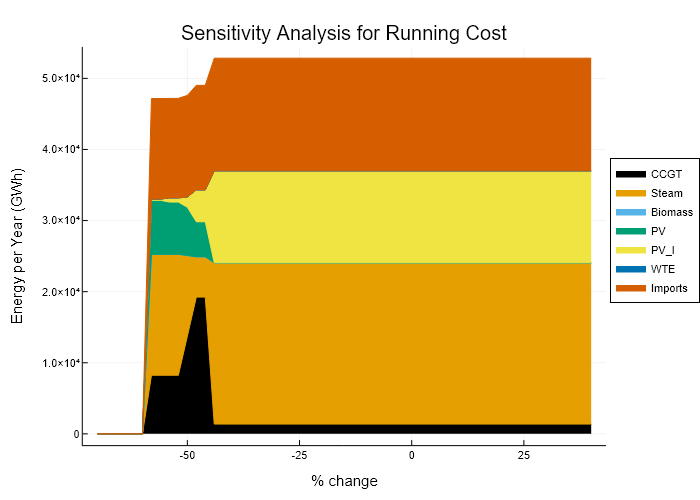

In [13]:
param = create_range(0.281, -70:2:40)
println(param)

running_costs_perMWh = [241, 241, 150, 110, 150, 102, 180]
running_costs_perWh = running_costs_perMWh/10^6

emissions_gperKWh = [670, 670, 1220, 40, 60, 1167, 110]
# emissions_gperKWh = [670, 465, 980, 1, 50, 775, 10]
emissions_gperWh = emissions_gperKWh / 10^3
carbon_tax = 80/1000000 # conversion of $/ton to $/gram
emissions_costs_perWh = emissions_gperWh.*carbon_tax
total_running_costs_perWh = emissions_costs_perWh + running_costs_perWh
total_running_costs_perKWh = total_running_costs_perWh * 1000

# function analyze_parameter_sensitivity(model, param_range, chosen_constraint)
current_energycost_perKWh = 0.281 # costs of electricity $0.281 / kWH
arr = zeros(Float64, length(param), 7)

for (j, new_cost) in enumerate(param)

    println("Analysing $(j), New Running Cost: $(new_cost)")
    # Modify RHS
    # println(new_cost, total_running_costs_perKWh)
    new_coeffs = new_cost .- total_running_costs_perKWh
    
    set_normalized_coefficient(c2, x[1], new_coeffs[1])
    set_normalized_coefficient(c2, x[2], new_coeffs[2])
    set_normalized_coefficient(c2, x[3], new_coeffs[3])
    set_normalized_coefficient(c2, x[4], new_coeffs[4])
    set_normalized_coefficient(c2, x[5], new_coeffs[5])
    set_normalized_coefficient(c2, x[6], new_coeffs[6])
    set_normalized_coefficient(c2, x[7], new_coeffs[7])

    
    optimize!(model)
    for (var_num, variable) in enumerate(all_variables(model))
        arr[j, var_num] = yearly_Wh_prod_per_tech[var_num]*value(variable)
    end
end
    # return arr
# end
println(arr)

using Plots

theme(:wong2)
areaplot(-70:2:40, 
arr, 
    label=["CCGT" "Steam" "Biomass" "PV" "PV_I" "WTE" "Imports"], 
    xlabel="% change", 
    ylabel="Energy per Year (GWh)", 
    title="Sensitivity Analysis for Running Cost",
    yformatter=y->round(Int64, y÷(10^9),),
    opacity=1,
)
plot!(legend=(1, 0.7), legend_columns=-1)


#### Land Area Sensitivity Analysis

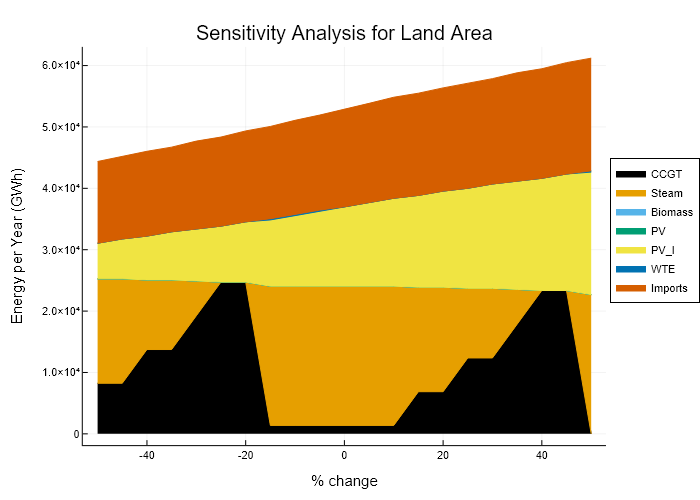

In [ ]:
intervals = create_range(2.1*10^7, percentage_change)
results = analyze_parameter_sensitivity(model, intervals, c1)


using Plots
theme(:wong2)

# Plot the stacked area chart
# plot(results, stacked=true, label=["CCGT"  "Steam"  "Biomass" "PV"  "PV_I"  "WTE"  "Imports"], xlabel="Area", ylabel="Value", title="Stacked Area Chart")
areaplot(percentage_change, 
    results, 
    label=["CCGT" "Steam" "Biomass" "PV" "PV_I" "WTE" "Imports"], 
    xlabel="% change", 
    ylabel="Energy per Year (GWh)", 
    title="Sensitivity Analysis for Land Area",
    yformatter=y->round(Int64, y÷(10^9),),
    opacity=1,
)
plot!(legend=(1, 0.7), legend_columns=-1)

#### Sensitivity Analysis for Emissions Limit

Analysing 9.39645e12
Analysing 9.584379e12
Analysing 9.772308e12
Analysing 9.960237e12
Analysing 1.0148166e13
Analysing 1.0336095e13
Analysing 1.0524024e13
Analysing 1.0711953e13
Analysing 1.0899882e13
Analysing 1.1087811e13
Analysing 1.127574e13
Analysing 1.1463669e13
Analysing 1.1651598e13
Analysing 1.1839527e13
Analysing 1.2027456e13
Analysing 1.2215385e13
Analysing 1.2403314e13
Analysing 1.2591243e13
Analysing 1.2779172e13
Analysing 1.2967101e13
Analysing 1.315503e13
Analysing 1.3342959e13
Analysing 1.3530888e13
Analysing 1.3718817e13
Analysing 1.3906746e13
Analysing 1.4094675e13
Analysing 1.4282604e13
Analysing 1.4470533e13
Analysing 1.4658462e13
Analysing 1.4846391e13
Analysing 1.503432e13
Analysing 1.5222249e13
Analysing 1.5410178e13
Analysing 1.5598107e13
Analysing 1.5786036e13
Analysing 1.5973965e13
Analysing 1.6161894e13
Analysing 1.6349823e13
Analysing 1.6537752e13
Analysing 1.6725681e13
Analysing 1.691361e13
Analysing 1.7101539e13
Analysing 1.7289468e13
Analysing 1.7477397e

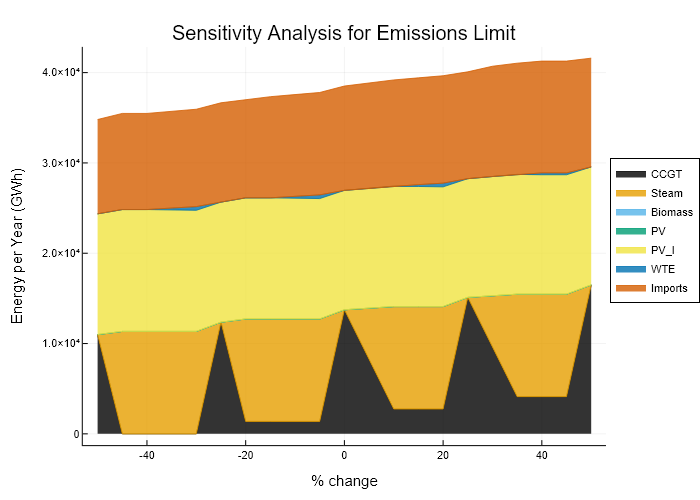

In [14]:
results = analyze_parameter_sensitivity(
    model, 
    create_range(normalized_rhs(c5), -50:1:50),
    c5)
using Plots

areaplot(percentage_change, 
    results, 
    label=["CCGT" "Steam" "Biomass" "PV" "PV_I" "WTE" "Imports"], 
    xlabel="% change", 
    ylabel="Energy per Year (GWh)", 
    title="Sensitivity Analysis for Emissions Limit",
    yformatter=y->round(Int64, y÷(10^9),),
    opacity=0.8,
)

plot!(legend=(1, 0.7), legend_columns=-1)

## Model 2

> Alternative model formulation with storage costs included

In [16]:
model = Model(Mosek.Optimizer)

@variable(model, x[1:7]>=0)
for i in 1:6
    set_integer(x[i]) # imports can be in decimal, while the rest are integers
end

@variable(model, z, Bin)

sizes = [114156, 366758, 130400, 3.5, 0.25, 61000, 0]

energy_prod_MWh = [470.5, 1942.5, 134, 0.00048, 0.000057, 69.5, 20000]
energy_prod_Wh = energy_prod_MWh * 10^6
yearly_Wh_prod_per_tech = energy_prod_Wh * (365*8)

running_costs_perMWh = [241, 241, 150, 110, 150, 102, 180]

running_costs_perWh = running_costs_perMWh/10^6

emissions_gperKWh = [670, 670, 1220, 40, 60, 1167, 110]
emissions_gperWh = emissions_gperKWh / 10^3
carbon_tax = 80/1000000 # conversion of $/ton to $/gram
emissions_costs_perWh = emissions_gperWh.*carbon_tax
total_running_costs_perWh = emissions_costs_perWh + running_costs_perWh
total_running_costs_perKWh = total_running_costs_perWh * 1000

@constraint(model, c1, sum(sizes.*x) <= 2.1*10^7  - 20000*z)

## Running Cost Constraint
current_energycost_perKWh = 0.281 # costs of electricity $0.281 / kWH

## Additional Costs Constraint for Energy Storage
total_running_costs_perKWh_plus_storage = copy(total_running_costs_perKWh)
total_running_costs_perKWh_plus_storage[5:6] .+= 0.15
Big_M = -10^11
@constraint(model, c2, sum((current_energycost_perKWh .- total_running_costs_perKWh).*x) >= Big_M*z)
@constraint(model, c7, sum((current_energycost_perKWh .- total_running_costs_perKWh_plus_storage).*x) >= Big_M*(1-z))

## Building Cost Constraint
yearly_depreciation_cost = [89.4, 96, 67, 0.1, 0.1, 104, 200] # made up import number
sg_annual_energy_budget = 10 * 10^9
# fixed depreciation costs in millions
@constraint(model, c3, sum(yearly_depreciation_cost.*x) <= sg_annual_energy_budget)

## Diversity Constraints
total_energy_prod_year = sum(yearly_Wh_prod_per_tech.*x)
@constraint(model, c4, yearly_Wh_prod_per_tech[7] * x[7] <= 0.3*total_energy_prod_year)

## Emissions Constraints
# ~471g of carbon dioxide per kWH of electricity generated
SG_yearly_Wh = 57*10^12 # total energy generation in a year

reduction_factor = 0.7
max_emissions_kg_per_yr = 27*10^6*10^4 * reduction_factor
emissionlimit_g_peryr = 471 / 10^3 * SG_yearly_Wh * reduction_factor
emissions_produced_g = emissions_gperWh .* yearly_Wh_prod_per_tech .* x
@constraint(model, c5, sum(emissions_produced_g) <= emissionlimit_g_peryr)


Big_M2 = 10^11
@constraint(model, c6,  x[4] + x[5] <= 6.2*10^5 - 1 + Big_M2*z)


@objective(model, Max, total_energy_prod_year)

print(model)
set_silent(model)

In [17]:
optimize!(model)

println("objective value $(objective_value(model)). Hence in gigawatt hours that would be about $(round(objective_value(model)/10^9, digits=2)) GWh. SG produced about 57,389 GWh in 2023.")
println("Is Z activated?", value(z))


for (i, variable) in enumerate(all_variables(model))
    production = yearly_Wh_prod_per_tech[i]*value(variable)
    percentage_of_total = round(production / objective_value(model)*100, digits=2)
    println("$(name(variable)) = $(value(variable)). This is $(percentage_of_total)% of the total. Raw value is $(round(production/10^9, digits=2)) GWh")
end

objective value 4.887213421588571e13. Hence in gigawatt hours that would be about 48872.13 GWh. SG produced about 57,389 GWh in 2023.
Is Z activated?1.0
x[1] = 14.0. This is 39.36% of the total. Raw value is 19234.04 GWh
x[2] = 1.0. This is 11.61% of the total. Raw value is 5672.1 GWh
x[3] = 0.0. This is 0.0% of the total. Raw value is 0.0 GWh
x[4] = 3.613241e6. This is 10.36% of the total. Raw value is 5064.32 GWh
x[5] = 2.5474858e7. This is 8.68% of the total. Raw value is 4240.04 GWh
x[6] = 0.0. This is 0.0% of the total. Raw value is 0.0 GWh
x[7] = 0.25105548398571426. This is 30.0% of the total. Raw value is 14661.64 GWh


LoadError: BoundsError: attempt to access 7-element Vector{Float64} at index [8]